# Logistic Regression: Predicting Employee Retention

## Problem Statement
A tech company faces high employee turnover. Using historical HR data, build a model to predict
which employees are likely to leave so the HR team can intervene proactively.

## Pipeline
1. Data Loading & Cleaning
2. Train / Validation Split
3. EDA for Training Set
4. EDA for Validation Set
5. Feature Engineering
6. Model Building (Scaling, RFE, VIF, Logistic Regression)
7. Finding Optimal Cutoff
8. Business Recommendations

In [1]:
#Adding imports
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.model_selection import train_test_split
from sklearn.linear_model import LogisticRegression
from sklearn.preprocessing import MinMaxScaler
from sklearn.feature_selection import RFE
from sklearn.metrics import (confusion_matrix, classification_report,
                             roc_auc_score, roc_curve, accuracy_score,
                             precision_recall_curve)
from statsmodels.stats.outliers_influence import variance_inflation_factor
import statsmodels.api as sm
import warnings
warnings.filterwarnings('ignore')

plt.rcParams['figure.figsize'] = (12, 5)
plt.rcParams['axes.spines.top'] = False
plt.rcParams['axes.spines.right'] = False

In [2]:
## 1. Load the Data
df = pd.read_csv('Employee_data.csv')

print(f'Shape: {df.shape}')
df.head()

Shape: (74610, 24)


,Employee ID,Age,Gender,Years at Company,Job Role,Monthly Income,Work-Life Balance,Job Satisfaction,Performance Rating,Number of Promotions,...,Number of Dependents,Job Level,Company Size,Company Tenure (In Months),Remote Work,Leadership Opportunities,Innovation Opportunities,Company Reputation,Employee Recognition,Attrition
0,8410,31,Male,19,Education,5390,Excellent,Medium,Average,2,...,0,Mid,Medium,89.0,No,No,No,Excellent,Medium,Stayed
1,64756,59,Female,4,Media,5534,Poor,High,Low,3,...,3,Mid,Medium,21.0,No,No,No,Fair,Low,Stayed
2,30257,24,Female,10,Healthcare,8159,Good,High,Low,0,...,3,Mid,Medium,74.0,No,No,No,Poor,Low,Stayed
3,65791,36,Female,7,Education,3989,Good,High,High,1,...,2,Mid,Small,50.0,Yes,No,No,Good,Medium,Stayed
4,65026,56,Male,41,Education,4821,Fair,Very High,Average,0,...,0,Senior,Medium,68.0,No,No,No,Fair,Medium,Stayed


In [4]:
## 1.2 Data Cleaning

# Checking missing values
print('Missing values:')
print(df.isnull().sum())
print(f'\nTarget distribution:')
print(df['Attrition'].value_counts())

Missing values:
Employee ID                      0
Age                              0
Gender                           0
Years at Company                 0
Job Role                         0
Monthly Income                   0
Work-Life Balance                0
Job Satisfaction                 0
Performance Rating               0
Number of Promotions             0
Overtime                         0
Distance from Home            1912
Education Level                  0
Marital Status                   0
Number of Dependents             0
Job Level                        0
Company Size                     0
Company Tenure (In Months)    2413
Remote Work                      0
Leadership Opportunities         0
Innovation Opportunities         0
Company Reputation               0
Employee Recognition             0
Attrition                        0
dtype: int64

Target distribution:
Attrition
Stayed    39191
Left      35419
Name: count, dtype: int64


In [5]:
# Check unique values in all categorical columns
cat_cols = df.select_dtypes(include='object').columns
for col in cat_cols:
    print(f'{col}: {sorted(df[col].unique())}')
    print()

Gender: ['Female', 'Male']

Job Role: ['Education', 'Finance', 'Healthcare', 'Media', 'Technology']

Work-Life Balance: ['Excellent', 'Fair', 'Good', 'Poor']

Job Satisfaction: ['High', 'Low', 'Medium', 'Very High']

Performance Rating: ['Average', 'Below Average', 'High', 'Low']

Overtime: ['No', 'Yes']

Education Level: ['Associate Degree', 'Bachelorâ€™s Degree', 'High School', 'Masterâ€™s Degree', 'PhD']

Marital Status: ['Divorced', 'Married', 'Single']

Job Level: ['Entry', 'Mid', 'Senior']

Company Size: ['Large', 'Medium', 'Small']

Remote Work: ['No', 'Yes']

Leadership Opportunities: ['No', 'Yes']

Innovation Opportunities: ['No', 'Yes']

Company Reputation: ['Excellent', 'Fair', 'Good', 'Poor']

Employee Recognition: ['High', 'Low', 'Medium', 'Very High']

Attrition: ['Left', 'Stayed']



In [6]:
# Fixing inconsistent categorical values
df['Work-Life Balance']   = df['Work-Life Balance'].replace('Fair', 'Below Average')
df['Job Satisfaction']    = df['Job Satisfaction'].replace('Very High', 'Very Low')
df['Employee Recognition']= df['Employee Recognition'].replace('Very High', 'Very Low')
df['Education Level']     = df['Education Level'].replace({
    'Bachelorâ€™s Degree': "Bachelor's Degree",
    'Masterâ€™s Degree':   "Master's Degree"
})

# Fixing mising values with median
df['Distance from Home']       = df['Distance from Home'].fillna(df['Distance from Home'].median())
df['Company Tenure (In Months)']= df['Company Tenure (In Months)'].fillna(df['Company Tenure (In Months)'].median())

# Dropping Employee ID as its not a predictive feature
df = df.drop(columns=['Employee ID'])

print('Fixes applied.')
print(df['Work-Life Balance'].unique())
print(df['Job Satisfaction'].unique())
print(df['Education Level'].unique())
print(f'Missing values remaining: {df.isnull().sum().sum()}')

Fixes applied.
['Excellent' 'Poor' 'Good' 'Below Average']
['Medium' 'High' 'Very Low' 'Low']
['Associate Degree' "Master's Degree" "Bachelor's Degree" 'High School'
 'PhD']
Missing values remaining: 0


In [7]:
## 2. Train / Validation Split

# Encode target: Stayed=0, Left=1
df['Attrition'] = df['Attrition'].map({'Stayed': 0, 'Left': 1})

X = df.drop(columns=['Attrition'])
y = df['Attrition']

X_train, X_val, y_train, y_val = train_test_split(X, y, test_size=0.2,
                                                   random_state=42,
                                                   stratify=y)

X_train = X_train.reset_index(drop=True)
X_val   = X_val.reset_index(drop=True)
y_train = y_train.reset_index(drop=True)
y_val   = y_val.reset_index(drop=True)

print(f'Training set  : {X_train.shape[0]:,} rows')
print(f'Validation set: {X_val.shape[0]:,} rows')
print(f'\nTrain attrition rate: {y_train.mean():.1%}')
print(f'Val   attrition rate: {y_val.mean():.1%}')

Training set  : 59,688 rows
Validation set: 14,922 rows

Train attrition rate: 47.5%
Val   attrition rate: 47.5%


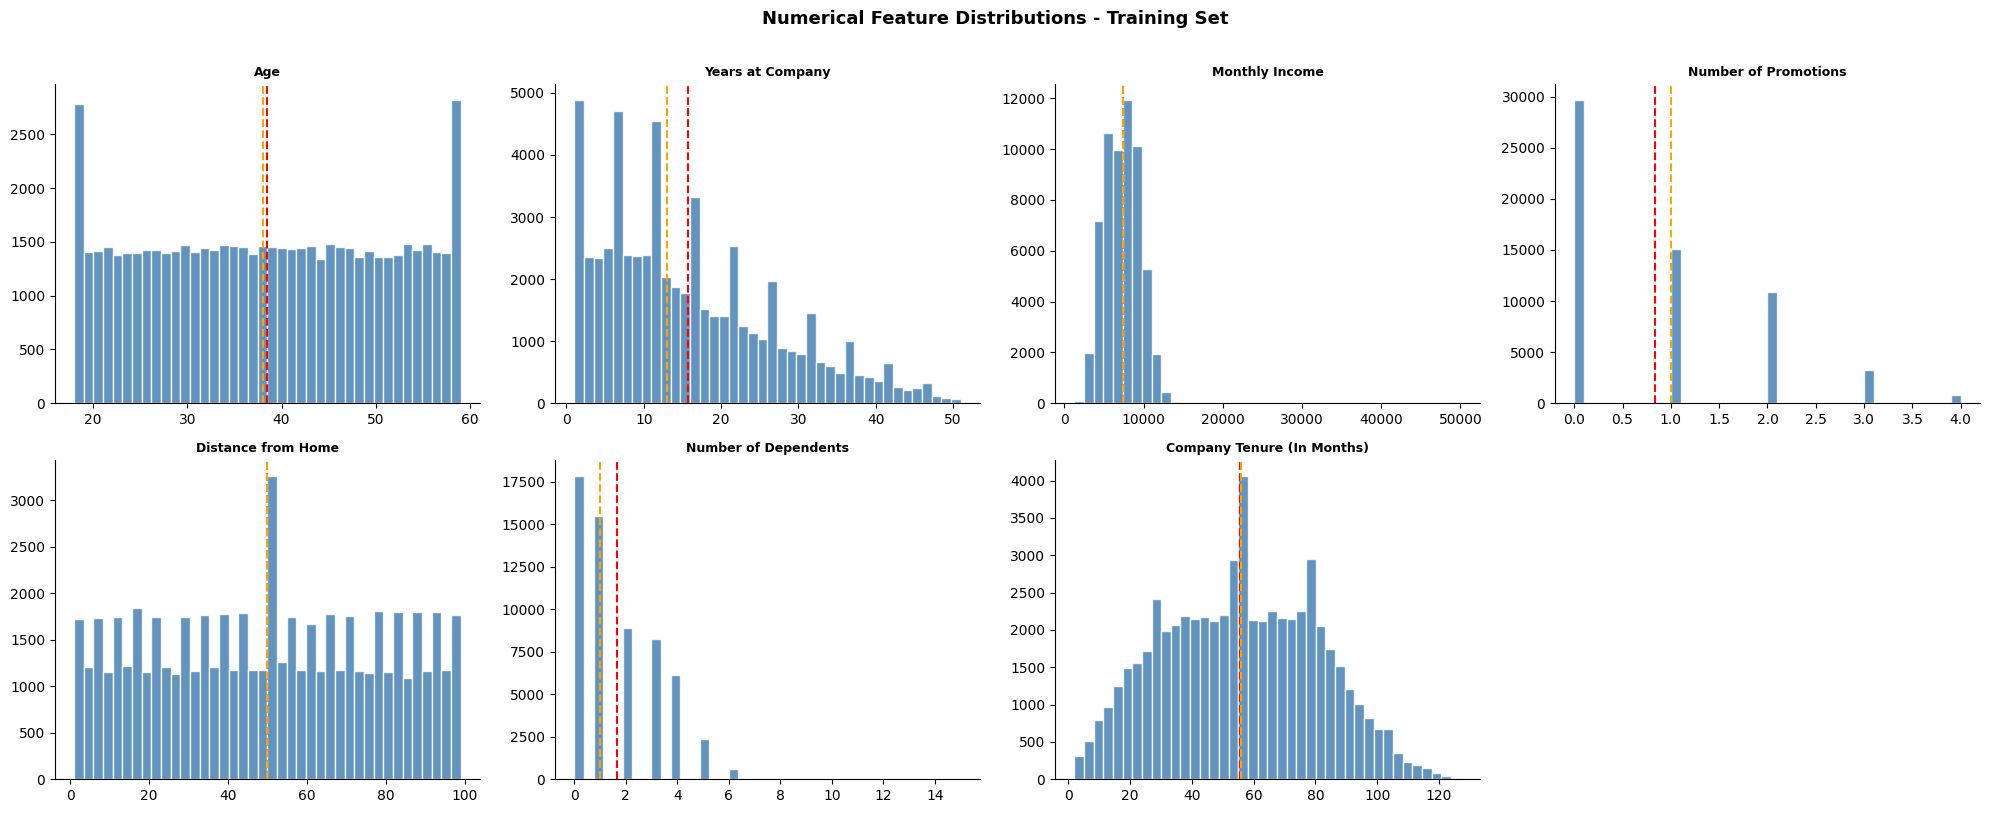

In [8]:
## 3. EDA for Training Set

# Combine train for EDA
train_df = X_train.copy()
train_df['Attrition'] = y_train

# 3.1 Numerical feature distributions
num_cols = ['Age', 'Years at Company', 'Monthly Income',
            'Number of Promotions', 'Distance from Home',
            'Number of Dependents', 'Company Tenure (In Months)']

fig, axes = plt.subplots(2, 4, figsize=(20, 8))
axes = axes.flatten()

for i, col in enumerate(num_cols):
    axes[i].hist(train_df[col], bins=40, color='steelblue', edgecolor='white', alpha=0.85)
    axes[i].axvline(train_df[col].mean(),   color='red',    linestyle='--', linewidth=1.5)
    axes[i].axvline(train_df[col].median(), color='orange', linestyle='--', linewidth=1.5)
    axes[i].set_title(col, fontsize=9, fontweight='bold')

axes[-1].axis('off')
plt.suptitle('Numerical Feature Distributions - Training Set', fontsize=13, fontweight='bold', y=1.01)
plt.tight_layout()
plt.show()

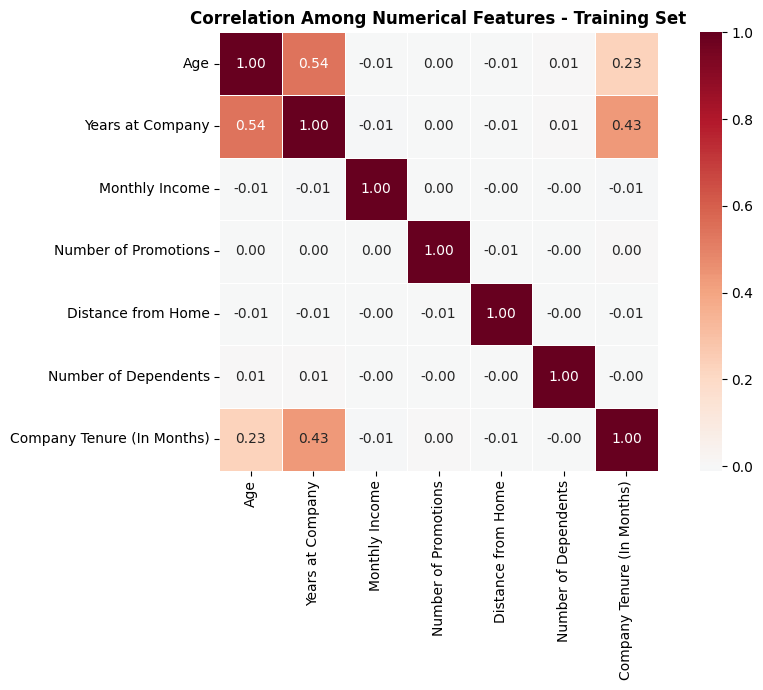

In [9]:
# 3.2 Multicolinearity check correlation heatmap
plt.figure(figsize=(10, 7))
corr = train_df[num_cols].corr()
sns.heatmap(corr, annot=True, fmt='.2f', cmap='RdBu_r', center=0,
            square=True, linewidths=0.5)
plt.title('Correlation Among Numerical Features - Training Set', fontweight='bold')
plt.tight_layout()
plt.show()

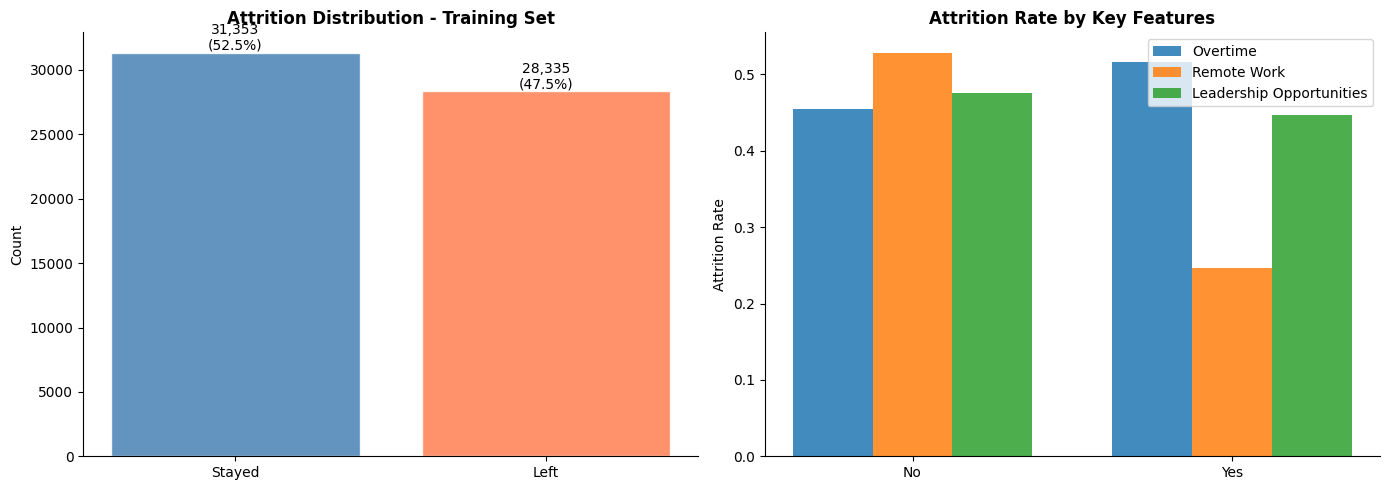

In [10]:
# 3.3 Target variable balance
fig, axes = plt.subplots(1, 2, figsize=(14, 5))

# Count plot
labels = ['Stayed', 'Left']
counts = train_df['Attrition'].value_counts().sort_index()
axes[0].bar(labels, counts.values, color=['steelblue', 'coral'], alpha=0.85, edgecolor='white')
axes[0].set_title('Attrition Distribution - Training Set', fontweight='bold')
axes[0].set_ylabel('Count')
for i, v in enumerate(counts.values):
    axes[0].text(i, v + 200, f'{v:,}\n({v/len(train_df):.1%})', ha='center', fontsize=10)

# Attrition rate by key categorical features
cat_attrition = {
    'Overtime':              train_df.groupby('Overtime')['Attrition'].mean(),
    'Remote Work':           train_df.groupby('Remote Work')['Attrition'].mean(),
    'Leadership Opportunities': train_df.groupby('Leadership Opportunities')['Attrition'].mean(),
}

x = np.arange(2)
width = 0.25
colors = ['steelblue', 'coral', 'mediumseagreen']
for i, (label, data) in enumerate(cat_attrition.items()):
    axes[1].bar(x + i*width, data.values, width, label=label, alpha=0.85)

axes[1].set_xticks(x + width)
axes[1].set_xticklabels(['No', 'Yes'])
axes[1].set_title('Attrition Rate by Key Features', fontweight='bold')
axes[1].set_ylabel('Attrition Rate')
axes[1].legend()

plt.tight_layout()
plt.show()

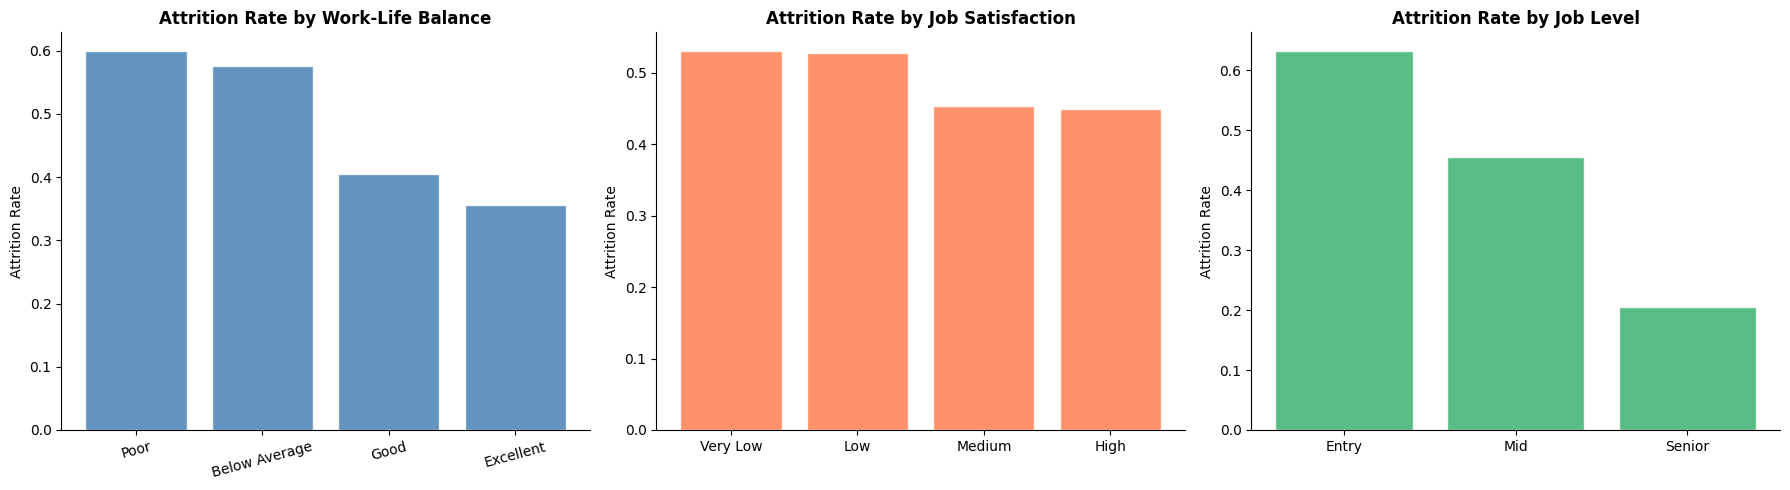

In [11]:
# 3.4 Attriton rate by ordinal categorical features
fig, axes = plt.subplots(1, 3, figsize=(18, 5))

# Work-Life Balance
wlb_order = ['Poor', 'Below Average', 'Good', 'Excellent']
wlb_data  = train_df.groupby('Work-Life Balance')['Attrition'].mean().reindex(wlb_order)
axes[0].bar(wlb_order, wlb_data.values, color='steelblue', alpha=0.85, edgecolor='white')
axes[0].set_title('Attrition Rate by Work-Life Balance', fontweight='bold')
axes[0].set_ylabel('Attrition Rate')
axes[0].tick_params(axis='x', rotation=15)

# Job Satisfaction
js_order  = ['Very Low', 'Low', 'Medium', 'High']
js_data   = train_df.groupby('Job Satisfaction')['Attrition'].mean().reindex(js_order)
axes[1].bar(js_order, js_data.values, color='coral', alpha=0.85, edgecolor='white')
axes[1].set_title('Attrition Rate by Job Satisfaction', fontweight='bold')
axes[1].set_ylabel('Attrition Rate')

# Job Level
jl_order  = ['Entry', 'Mid', 'Senior']
jl_data   = train_df.groupby('Job Level')['Attrition'].mean().reindex(jl_order)
axes[2].bar(jl_order, jl_data.values, color='mediumseagreen', alpha=0.85, edgecolor='white')
axes[2].set_title('Attrition Rate by Job Level', fontweight='bold')
axes[2].set_ylabel('Attrition Rate')

plt.tight_layout()
plt.show()

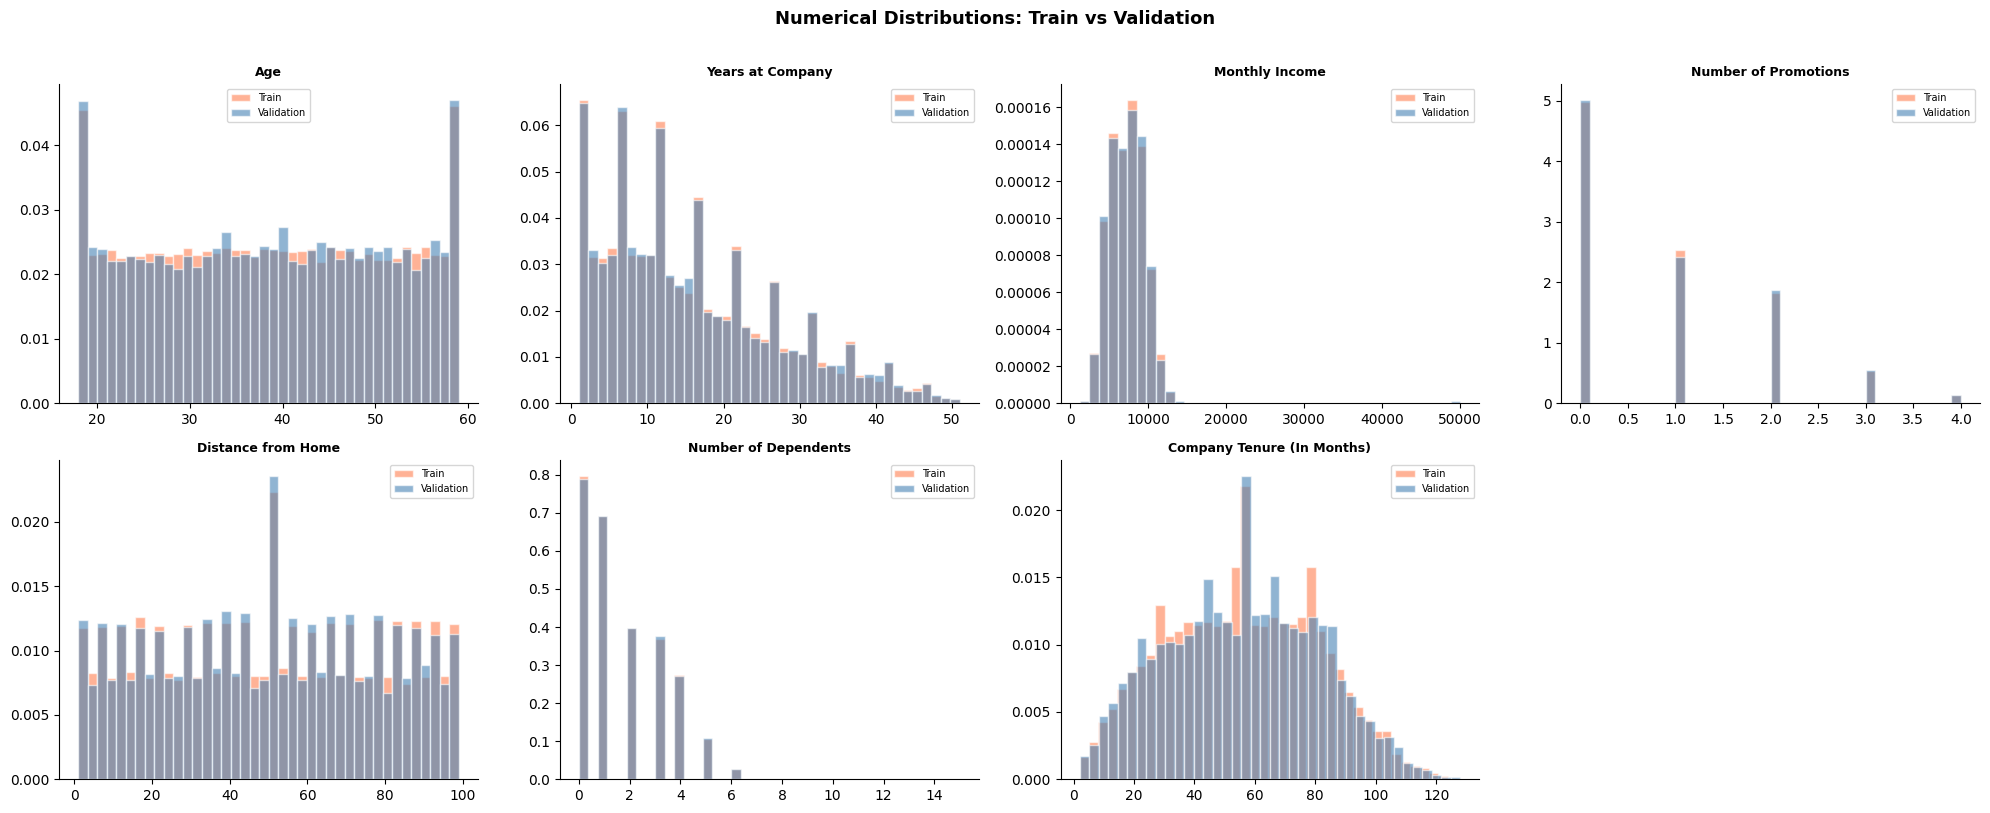

In [13]:
## 4. EDA for Validation Set

val_df = X_val.copy()
val_df['Attrition'] = y_val

# 4.1 Comparing numerical distributions
fig, axes = plt.subplots(2, 4, figsize=(20, 8))
axes = axes.flatten()

for i, col in enumerate(num_cols):
    axes[i].hist(train_df[col], bins=40, color='coral',     alpha=0.6, label='Train',      density=True, edgecolor='white')
    axes[i].hist(val_df[col],   bins=40, color='steelblue', alpha=0.6, label='Validation', density=True, edgecolor='white')
    axes[i].set_title(col, fontsize=9, fontweight='bold')
    axes[i].legend(fontsize=7)

axes[-1].axis('off')
plt.suptitle('Numerical Distributions: Train vs Validation', fontsize=13, fontweight='bold', y=1.01)
plt.tight_layout()
plt.show()

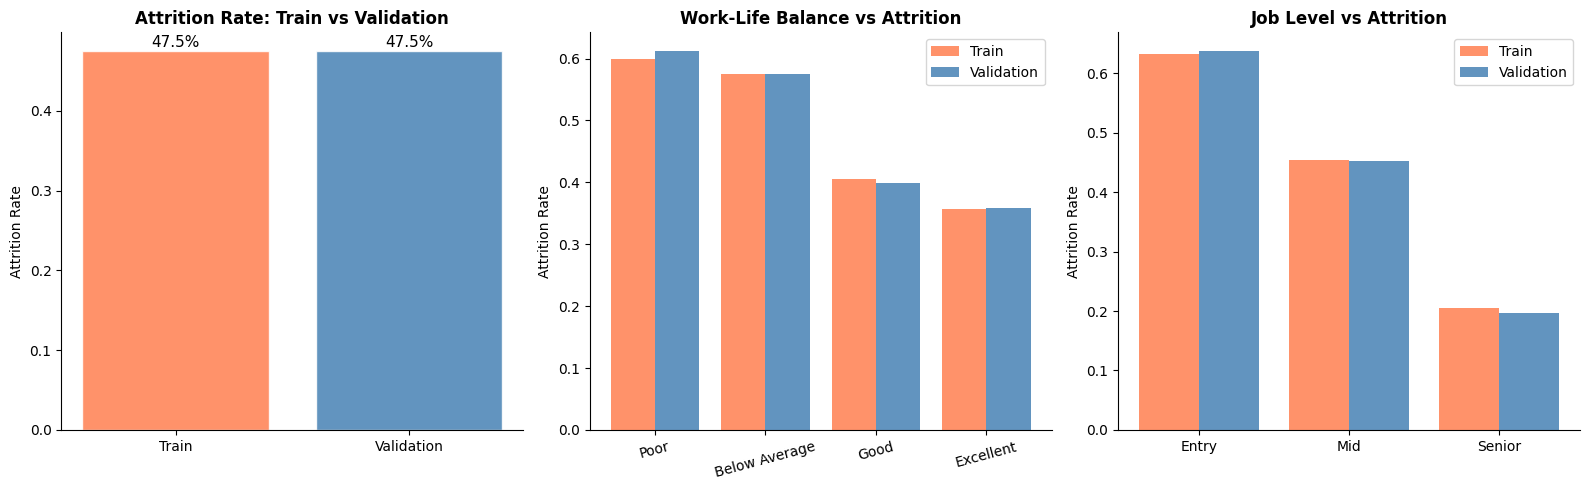

In [14]:
# 4.2 Comparing attrition rate and categorical patterns
fig, axes = plt.subplots(1, 3, figsize=(16, 5))

# Attrition rate comparison
rates = [y_train.mean(), y_val.mean()]
axes[0].bar(['Train', 'Validation'], rates, color=['coral', 'steelblue'], alpha=0.85, edgecolor='white')
axes[0].set_title('Attrition Rate: Train vs Validation', fontweight='bold')
axes[0].set_ylabel('Attrition Rate')
for i, v in enumerate(rates):
    axes[0].text(i, v + 0.005, f'{v:.1%}', ha='center', fontsize=11)

# Work-Life Balance attrition comparison
wlb_train = train_df.groupby('Work-Life Balance')['Attrition'].mean().reindex(wlb_order)
wlb_val   = val_df.groupby('Work-Life Balance')['Attrition'].mean().reindex(wlb_order)
x = np.arange(len(wlb_order))
axes[1].bar(x - 0.2, wlb_train.values, 0.4, label='Train',      color='coral',     alpha=0.85)
axes[1].bar(x + 0.2, wlb_val.values,   0.4, label='Validation', color='steelblue', alpha=0.85)
axes[1].set_xticks(x)
axes[1].set_xticklabels(wlb_order, rotation=15)
axes[1].set_title('Work-Life Balance vs Attrition', fontweight='bold')
axes[1].set_ylabel('Attrition Rate')
axes[1].legend()

# Job Level attrition comparison
jl_train = train_df.groupby('Job Level')['Attrition'].mean().reindex(jl_order)
jl_val   = val_df.groupby('Job Level')['Attrition'].mean().reindex(jl_order)
x = np.arange(len(jl_order))
axes[2].bar(x - 0.2, jl_train.values, 0.4, label='Train',      color='coral',     alpha=0.85)
axes[2].bar(x + 0.2, jl_val.values,   0.4, label='Validation', color='steelblue', alpha=0.85)
axes[2].set_xticks(x)
axes[2].set_xticklabels(jl_order)
axes[2].set_title('Job Level vs Attrition', fontweight='bold')
axes[2].set_ylabel('Attrition Rate')
axes[2].legend()

plt.tight_layout()
plt.show()

In [16]:
## 5. Feature Engineering

# 5.1 Ordinal encoding we r doing to preserve its natural order
ordinal_maps = {
    'Work-Life Balance':   {'Poor': 1, 'Below Average': 2, 'Good': 3, 'Excellent': 4},
    'Job Satisfaction':    {'Very Low': 1, 'Low': 2, 'Medium': 3, 'High': 4},
    'Performance Rating':  {'Low': 1, 'Below Average': 2, 'Average': 3, 'High': 4},
    'Company Reputation':  {'Poor': 1, 'Fair': 2, 'Good': 3, 'Excellent': 4},
    'Employee Recognition':{'Very Low': 1, 'Low': 2, 'Medium': 3, 'High': 4},
    'Education Level':     {'High School': 1, 'Associate Degree': 2,
                            "Bachelor's Degree": 3, "Master's Degree": 4, 'PhD': 5},
    'Job Level':           {'Entry': 1, 'Mid': 2, 'Senior': 3},
    'Company Size':        {'Small': 1, 'Medium': 2, 'Large': 3},
}

for col, mapping in ordinal_maps.items():
    X_train[col] = X_train[col].map(mapping)
    X_val[col]   = X_val[col].map(mapping)

print('Ordinal encoding done.')
print(X_train[list(ordinal_maps.keys())].head(3))

Ordinal encoding done.
   Work-Life Balance  Job Satisfaction  Performance Rating  \
0                  3                 2                   1   
1                  2                 4                   1   
2                  1                 1                   3   

   Company Reputation  Employee Recognition  Education Level  Job Level  \
0                   1                     1                3          2   
1                   3                     3                3          3   
2                   3                     3                1          2   

   Company Size  
0             2  
1             2  
2             1  


In [17]:
# 5.2 One-hot encode nominal categorical columns
nominal_cols = ['Gender', 'Job Role', 'Marital Status',
                'Overtime', 'Remote Work',
                'Leadership Opportunities', 'Innovation Opportunities']

X_train = pd.get_dummies(X_train, columns=nominal_cols, drop_first=True)
X_val   = pd.get_dummies(X_val,   columns=nominal_cols, drop_first=True)

# Convert booleans to int
X_train = X_train.astype({col: int for col in X_train.select_dtypes('bool').columns})
X_val   = X_val.astype({col: int for col in X_val.select_dtypes('bool').columns})

print(f'X_train shape: {X_train.shape}')
print(f'Columns: {X_train.columns.tolist()}')

X_train shape: (59688, 26)
Columns: ['Age', 'Years at Company', 'Monthly Income', 'Work-Life Balance', 'Job Satisfaction', 'Performance Rating', 'Number of Promotions', 'Distance from Home', 'Education Level', 'Number of Dependents', 'Job Level', 'Company Size', 'Company Tenure (In Months)', 'Company Reputation', 'Employee Recognition', 'Gender_Male', 'Job Role_Finance', 'Job Role_Healthcare', 'Job Role_Media', 'Job Role_Technology', 'Marital Status_Married', 'Marital Status_Single', 'Overtime_Yes', 'Remote Work_Yes', 'Leadership Opportunities_Yes', 'Innovation Opportunities_Yes']


In [18]:
## 6. Model Building

# 6.1 Feature Scaling MinMaxScaler on continuous columns only
scale_cols = ['Age', 'Years at Company', 'Monthly Income',
              'Number of Promotions', 'Distance from Home',
              'Number of Dependents', 'Company Tenure (In Months)']

scaler = MinMaxScaler()
X_train[scale_cols] = scaler.fit_transform(X_train[scale_cols])
X_val[scale_cols]   = scaler.transform(X_val[scale_cols])

print('Scaling done.')
X_train[scale_cols].describe().round(3)

Scaling done.


,Age,Years at Company,Monthly Income,Number of Promotions,Distance from Home,Number of Dependents,Company Tenure (In Months)
count,59688.000,59688.000,59688.000,59688.000,59688.000,59688.000,59688.000
mean,0.500,0.295,0.125,0.208,0.500,0.110,0.430
std,0.295,0.224,0.053,0.248,0.288,0.105,0.200
min,0.000,0.000,0.000,0.000,0.000,0.000,0.000
25%,0.244,0.120,0.090,0.000,0.255,0.000,0.272
50%,0.488,0.240,0.125,0.250,0.500,0.067,0.432
75%,0.756,0.440,0.156,0.250,0.745,0.200,0.584
max,1.000,1.000,1.000,1.000,1.000,1.000,1.000


In [19]:
# 6.2 RFE to select top 15 features
rfe = RFE(LogisticRegression(max_iter=1000, random_state=42), n_features_to_select=15)
rfe.fit(X_train, y_train)

selected_features = list(X_train.columns[rfe.support_])
print(f'Selected {len(selected_features)} features:')
for i, f in enumerate(selected_features, 1):
    print(f'  {i}. {f}')

Selected 15 features:
  1. Age
  2. Years at Company
  3. Monthly Income
  4. Work-Life Balance
  5. Job Satisfaction
  6. Number of Promotions
  7. Distance from Home
  8. Number of Dependents
  9. Job Level
  10. Company Reputation
  11. Gender_Male
  12. Marital Status_Married
  13. Marital Status_Single
  14. Overtime_Yes
  15. Remote Work_Yes


In [20]:
# 6.3 VIF check on selected features (multicoll check)
X_train_sel = X_train[selected_features]

vif_data = pd.DataFrame()
vif_data['Feature'] = selected_features
vif_data['VIF']     = [variance_inflation_factor(X_train_sel.values, i)
                        for i in range(X_train_sel.shape[1])]

print(vif_data.sort_values('VIF', ascending=False).round(2).to_string(index=False))

               Feature  VIF
     Work-Life Balance 7.37
    Company Reputation 7.05
      Job Satisfaction 6.41
             Job Level 5.99
        Monthly Income 5.84
                   Age 5.32
Marital Status_Married 3.91
      Years at Company 3.82
    Distance from Home 3.78
 Marital Status_Single 3.02
           Gender_Male 2.16
  Number of Dependents 2.05
  Number of Promotions 1.68
          Overtime_Yes 1.47
       Remote Work_Yes 1.23


In [21]:
# 6.4 Building base model with statsmodels to check p-values
X_train_sm = sm.add_constant(X_train[selected_features])
sm_model   = sm.Logit(y_train, X_train_sm).fit()
print(sm_model.summary())

Optimization terminated successfully.
         Current function value: 0.503316
         Iterations 6
                           Logit Regression Results                           
Dep. Variable:              Attrition   No. Observations:                59688
Model:                          Logit   Df Residuals:                    59672
Method:                           MLE   Df Model:                           15
Date:                Sun, 31 May 2026   Pseudo R-squ.:                  0.2725
Time:                        14:43:21   Log-Likelihood:                -30042.
converged:                       True   LL-Null:                       -41296.
Covariance Type:            nonrobust   LLR p-value:                     0.000
                             coef    std err          z      P>|z|      [0.025      0.975]
------------------------------------------------------------------------------------------
const                      5.3619      0.077     69.659      0.000       5.211      

In [22]:
# 6.5 Re-checking VIF on final feature set as pre step all features r imp
vif_final = pd.DataFrame({
    'Feature': selected_features,
    'VIF': [variance_inflation_factor(X_train[selected_features].values, i)
            for i in range(len(selected_features))]
}).sort_values('VIF', ascending=False)

print(vif_final.to_string(index=False))

               Feature      VIF
     Work-Life Balance 7.365881
    Company Reputation 7.046386
      Job Satisfaction 6.406870
             Job Level 5.987361
        Monthly Income 5.840949
                   Age 5.319914
Marital Status_Married 3.909983
      Years at Company 3.824073
    Distance from Home 3.778201
 Marital Status_Single 3.020951
           Gender_Male 2.157105
  Number of Dependents 2.052144
  Number of Promotions 1.676933
          Overtime_Yes 1.468977
       Remote Work_Yes 1.230037


In [24]:
# 6.6 Iterative VIF reduction dropping highest VIF feature
features_vif = selected_features.copy()
features_vif.remove('Work-Life Balance')

vif_iter = pd.DataFrame({
    'Feature': features_vif,
    'VIF': [variance_inflation_factor(X_train[features_vif].values, i)
            for i in range(len(features_vif))]
}).sort_values('VIF', ascending=False)

print(vif_iter.to_string(index=False))

               Feature      VIF
    Company Reputation 6.817649
      Job Satisfaction 6.248601
             Job Level 5.841603
        Monthly Income 5.698211
                   Age 5.285139
Marital Status_Married 3.829598
      Years at Company 3.821714
    Distance from Home 3.721823
 Marital Status_Single 2.963305
           Gender_Male 2.144646
  Number of Dependents 2.044565
  Number of Promotions 1.673109
          Overtime_Yes 1.466891
       Remote Work_Yes 1.228910


In [25]:
# Drop Company Reputation
features_vif.remove('Company Reputation')

vif_iter = pd.DataFrame({
    'Feature': features_vif,
    'VIF': [variance_inflation_factor(X_train[features_vif].values, i)
            for i in range(len(features_vif))]
}).sort_values('VIF', ascending=False)

print(vif_iter.to_string(index=False))

               Feature      VIF
      Job Satisfaction 6.021981
             Job Level 5.640216
        Monthly Income 5.516536
                   Age 5.244850
      Years at Company 3.817103
Marital Status_Married 3.709631
    Distance from Home 3.654683
 Marital Status_Single 2.883874
           Gender_Male 2.132391
  Number of Dependents 2.033765
  Number of Promotions 1.665789
          Overtime_Yes 1.463502
       Remote Work_Yes 1.227130


In [26]:
# Drop Job Satisfaction
features_vif.remove('Job Satisfaction')

vif_iter = pd.DataFrame({
    'Feature': features_vif,
    'VIF': [variance_inflation_factor(X_train[features_vif].values, i)
            for i in range(len(features_vif))]
}).sort_values('VIF', ascending=False)

print(vif_iter.to_string(index=False))

               Feature      VIF
             Job Level 5.374087
        Monthly Income 5.232838
                   Age 5.196492
      Years at Company 3.811360
    Distance from Home 3.575522
Marital Status_Married 3.569589
 Marital Status_Single 2.782512
           Gender_Male 2.115738
  Number of Dependents 2.021634
  Number of Promotions 1.658421
          Overtime_Yes 1.458796
       Remote Work_Yes 1.225527


In [27]:
# Drop Job Level
features_vif.remove('Job Level')

vif_iter = pd.DataFrame({
    'Feature': features_vif,
    'VIF': [variance_inflation_factor(X_train[features_vif].values, i)
            for i in range(len(features_vif))]
}).sort_values('VIF', ascending=False)

print(vif_iter.to_string(index=False))

               Feature      VIF
                   Age 5.129926
        Monthly Income 4.889151
      Years at Company 3.801014
    Distance from Home 3.462498
Marital Status_Married 3.357334
 Marital Status_Single 2.638539
           Gender_Male 2.089860
  Number of Dependents 1.999232
  Number of Promotions 1.648158
          Overtime_Yes 1.452880
       Remote Work_Yes 1.222873


In [28]:
# Drop Age
features_vif.remove('Age')

vif_iter = pd.DataFrame({
    'Feature': features_vif,
    'VIF': [variance_inflation_factor(X_train[features_vif].values, i)
            for i in range(len(features_vif))]
}).sort_values('VIF', ascending=False)

print(vif_iter.to_string(index=False))

               Feature      VIF
        Monthly Income 4.778672
    Distance from Home 3.426849
Marital Status_Married 3.292824
 Marital Status_Single 2.590670
      Years at Company 2.492306
           Gender_Male 2.082605
  Number of Dependents 1.991957
  Number of Promotions 1.644483
          Overtime_Yes 1.450041
       Remote Work_Yes 1.221925


In [29]:
# 6.7 Refit statsmodels on VIF-clean features
X_train_sm2 = sm.add_constant(X_train[features_vif])
sm_model2   = sm.Logit(y_train, X_train_sm2).fit()
print(sm_model2.summary())

Optimization terminated successfully.
         Current function value: 0.600065
         Iterations 5
                           Logit Regression Results                           
Dep. Variable:              Attrition   No. Observations:                59688
Model:                          Logit   Df Residuals:                    59677
Method:                           MLE   Df Model:                           10
Date:                Sun, 31 May 2026   Pseudo R-squ.:                  0.1327
Time:                        14:51:17   Log-Likelihood:                -35817.
converged:                       True   LL-Null:                       -41296.
Covariance Type:            nonrobust   LLR p-value:                     0.000
                             coef    std err          z      P>|z|      [0.025      0.975]
------------------------------------------------------------------------------------------
const                      0.2389      0.040      5.901      0.000       0.160      

In [30]:
## 7. Model Training n Base Evaluation

model = LogisticRegression(max_iter=1000, random_state=42)
model.fit(X_train[features_vif], y_train)

# Predictions at default 0.5 threshold
y_pred_train = model.predict(X_train[features_vif])
y_pred_val   = model.predict(X_val[features_vif])
y_prob_val   = model.predict_proba(X_val[features_vif])[:, 1]

# 7.1 Base evaluation at 0.5 threshold
cm = confusion_matrix(y_val, y_pred_val)
tn, fp, fn, tp = cm.ravel()

print('Base Model on Validation Set (threshold = 0.50)')
print('=' * 45)
print(f'  Accuracy    : {accuracy_score(y_val, y_pred_val):.4f}')
print(f'  Sensitivity : {tp / (tp + fn):.4f}')
print(f'  Specificity : {tn / (tn + fp):.4f}')
print(f'\nConfusion Matrix:\n{cm}')
print(f'\n{classification_report(y_val, y_pred_val, target_names=["Stayed", "Left"])}')

Base Model on Validation Set (threshold = 0.50)
  Accuracy    : 0.6659
  Sensitivity : 0.5896
  Specificity : 0.7348

Confusion Matrix:
[[5759 2079]
 [2907 4177]]

              precision    recall  f1-score   support

      Stayed       0.66      0.73      0.70      7838
        Left       0.67      0.59      0.63      7084

    accuracy                           0.67     14922
   macro avg       0.67      0.66      0.66     14922
weighted avg       0.67      0.67      0.66     14922



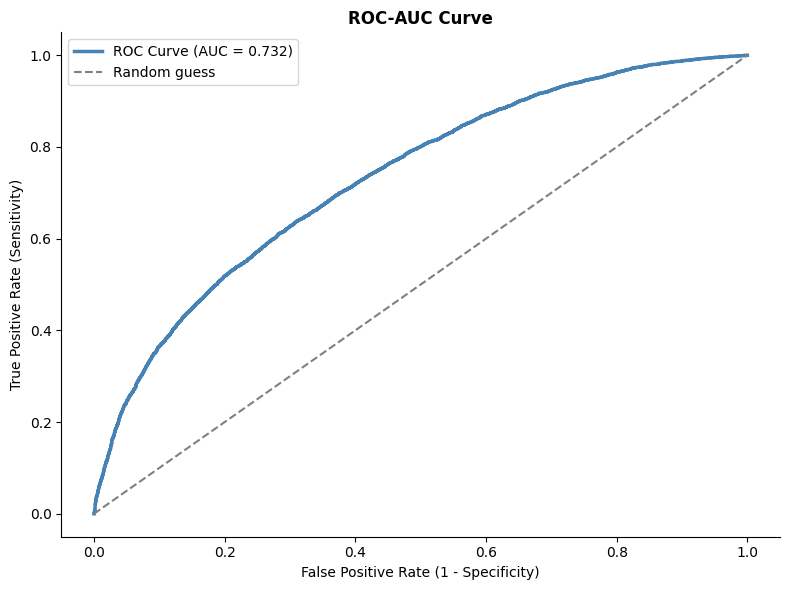

AUC: 0.7323


In [31]:
## 8. Finding Optimal Cutoff

# 8.1 ROC Curve
fpr, tpr, thresholds = roc_curve(y_val, y_prob_val)
auc = roc_auc_score(y_val, y_prob_val)

plt.figure(figsize=(8, 6))
plt.plot(fpr, tpr, color='steelblue', linewidth=2.5, label=f'ROC Curve (AUC = {auc:.3f})')
plt.plot([0, 1], [0, 1], color='gray', linestyle='--', linewidth=1.5, label='Random guess')
plt.xlabel('False Positive Rate (1 - Specificity)')
plt.ylabel('True Positive Rate (Sensitivity)')
plt.title('ROC-AUC Curve', fontweight='bold')
plt.legend()
plt.tight_layout()
plt.show()

print(f'AUC: {auc:.4f}')

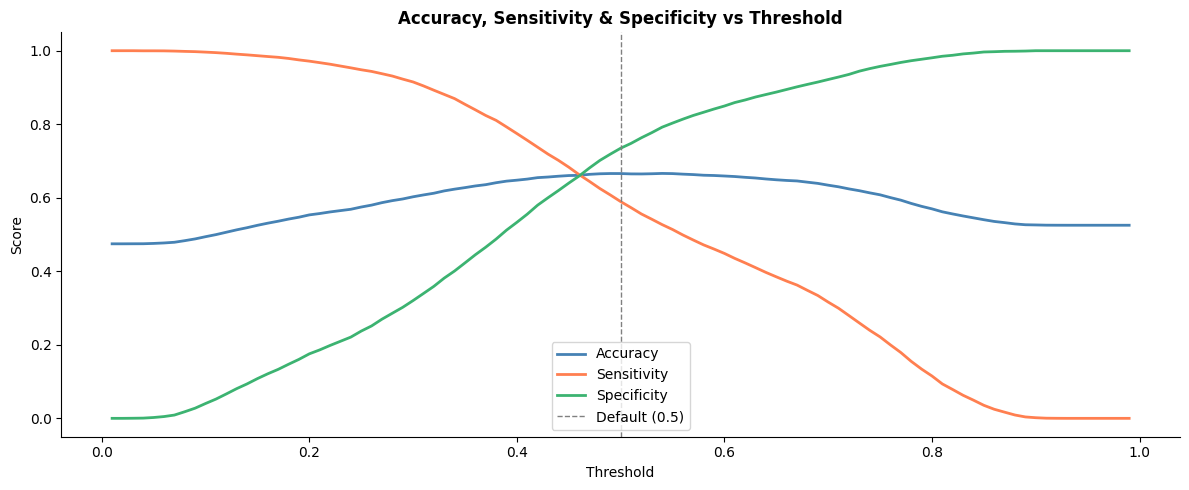

In [32]:
# 8.2 Threshold analysis
thresh_range = np.arange(0.01, 1.0, 0.01)
results = []

for t in thresh_range:
    y_pred_t = (y_prob_val >= t).astype(int)
    cm_t = confusion_matrix(y_val, y_pred_t)
    tn_t, fp_t, fn_t, tp_t = cm_t.ravel()
    results.append({
        'Threshold':   round(t, 2),
        'Accuracy':    accuracy_score(y_val, y_pred_t),
        'Sensitivity': tp_t / (tp_t + fn_t),
        'Specificity': tn_t / (tn_t + fp_t)
    })

thresh_df = pd.DataFrame(results)

plt.figure(figsize=(12, 5))
plt.plot(thresh_df['Threshold'], thresh_df['Accuracy'],    label='Accuracy',    color='steelblue', linewidth=2)
plt.plot(thresh_df['Threshold'], thresh_df['Sensitivity'], label='Sensitivity', color='coral',     linewidth=2)
plt.plot(thresh_df['Threshold'], thresh_df['Specificity'], label='Specificity', color='mediumseagreen', linewidth=2)
plt.axvline(0.5, color='gray', linestyle='--', linewidth=1, label='Default (0.5)')
plt.xlabel('Threshold')
plt.ylabel('Score')
plt.title('Accuracy, Sensitivity & Specificity vs Threshold', fontweight='bold')
plt.legend()
plt.tight_layout()
plt.show()

In [33]:
# 8.3 Lets Find optimal cutoff where |sensitivity - specificity| is minimised
thresh_df['diff'] = abs(thresh_df['Sensitivity'] - thresh_df['Specificity'])
optimal_row = thresh_df.loc[thresh_df['diff'].idxmin()]
optimal_cutoff = optimal_row['Threshold']

print(f'Optimal Cutoff  : {optimal_cutoff}')
print(f'Accuracy        : {optimal_row["Accuracy"]:.4f}')
print(f'Sensitivity     : {optimal_row["Sensitivity"]:.4f}')
print(f'Specificity     : {optimal_row["Specificity"]:.4f}')

Optimal Cutoff  : 0.46
Accuracy        : 0.6610
Sensitivity     : 0.6629
Specificity     : 0.6592


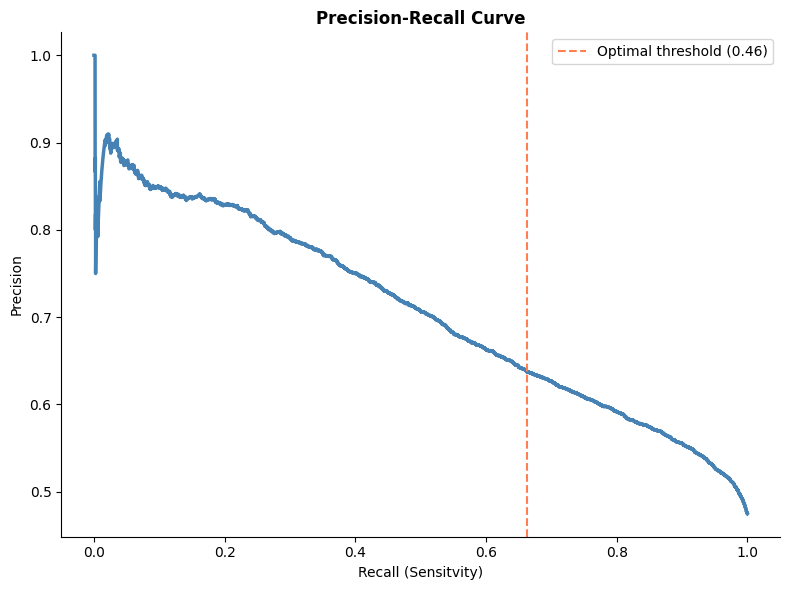

In [36]:
# 8.4 Precision-Recall Curve
precision, recall, pr_thresholds = precision_recall_curve(y_val, y_prob_val)

plt.figure(figsize=(8, 6))
plt.plot(recall, precision, color='steelblue', linewidth=2.5)
plt.axvline(optimal_row['Sensitivity'], color='coral', linestyle='--', linewidth=1.5,
            label=f'Optimal threshold ({optimal_cutoff})')
plt.xlabel('Recall (Sensitvity)')
plt.ylabel('Precision')
plt.title('Precision-Recall Curve', fontweight='bold')
plt.legend()
plt.tight_layout()
plt.show()

Final Model for Validation Set (threshold = 0.46)
  Accuracy    : 0.6610
  Sensitvity : 0.6629
  Specificity : 0.6592
  Precision   : 0.6374

Confusion Matrix:
[[5167 2671]
 [2388 4696]]


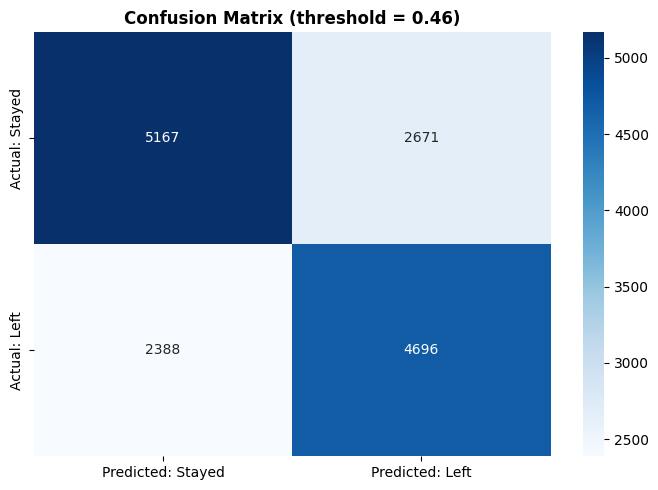

In [37]:
# 8.5 Final evaluation at optimal cutoff
y_pred_final = (y_prob_val >= optimal_cutoff).astype(int)
cm_final = confusion_matrix(y_val, y_pred_final)
tn_f, fp_f, fn_f, tp_f = cm_final.ravel()

print(f'Final Model for Validation Set (threshold = {optimal_cutoff})')
print('=' * 50)
print(f'  Accuracy    : {accuracy_score(y_val, y_pred_final):.4f}')
print(f'  Sensitvity : {tp_f / (tp_f + fn_f):.4f}')
print(f'  Specificity : {tn_f / (tn_f + fp_f):.4f}')
print(f'  Precision   : {tp_f / (tp_f + fp_f):.4f}')
print('=' * 50)
print(f'\nConfusion Matrix:\n{cm_final}')

plt.figure(figsize=(7, 5))
sns.heatmap(cm_final, annot=True, fmt='d', cmap='Blues',
            xticklabels=['Predicted: Stayed', 'Predicted: Left'],
            yticklabels=['Actual: Stayed',    'Actual: Left'])
plt.title(f'Confusion Matrix (threshold = {optimal_cutoff})', fontweight='bold')
plt.tight_layout()
plt.show()

In [38]:
# 8.6 Model Summary
print('MODEL PERFORMANCE SUMMARY')
print('=' * 50)
print(f'{"Metric":<20} {"Base (0.50)":>12} {"Optimal (0.46)":>15}')
print('-' * 50)
print(f'{"Accuracy":<20} {"0.6659":>12} {"0.6610":>15}')
print(f'{"Sensitivity":<20} {"0.5896":>12} {"0.6629":>15}')
print(f'{"Specificity":<20} {"0.7348":>12} {"0.6592":>15}')
print(f'{"AUC":<20} {"0.7323":>12} {"0.7323":>15}')
print('=' * 50)
print('\nKey insight: Lowering threshold from 0.50 to 0.46')
print('catches 770 more at-risk employees at the cost of')
print('756 more false alarms — a worthwhile trade for HR.')

MODEL PERFORMANCE SUMMARY
Metric                Base (0.50)  Optimal (0.46)
--------------------------------------------------
Accuracy                   0.6659          0.6610
Sensitivity                0.5896          0.6629
Specificity                0.7348          0.6592
AUC                        0.7323          0.7323

Key insight: Lowering threshold from 0.50 to 0.46
catches 770 more at-risk employees at the cost of
756 more false alarms — a worthwhile trade for HR.


## 9. Business Recommendations

**Q1. What are the strongest predictors of attrition?**

> - Remote work access is the single strongest retention factor (coef = -1.41). Employees
>   without remote work options are significantly more likely to leave.
> - Number of dependents reduces attrition sharply (coef = -1.67) employees with family
>   responsibilities are more stable.
> - Single employees have the highest flight risk (coef = +1.20).
> - Long comutes strongly increase attrition (coef = +0.76) distance from home is the
>   top push factor.
> - Overtime increases attrition risk (coef = +0.31)  overworked employees are more likely
>   to leave. (Burnout)

**Q2. What interventions should HR prioritise?**

> - **Expand remote work**: It is the most powerful lever. Offer hybrid or full-remote options
>   to employees flagged as high-risk.
> - **Target single employees**: Design engagement programmes (mentorship, career growth
>   paths, social events) specifically for single employees who lack anchoring factors.
> - **Reduce commute burden**: Offer transport allowances, relocation support, or flexible
>   hours for employees with long commutes.
> - **Manage overtime**: Cap or compensate overtime fairly. Chronic overtime is a clear
>   attrition signal.
> - **Reward tenure and promotions**: Employees with more promotions stay longer structured
>   career progression is a retention investment. (Feel more valued)

**Q3. How should the model be used operationally?**

> - Run the model monthly on current employee data. Flag anyone with predicted probability > or = 0.46 as high-risk.
> - Prioritise intervention for employees who combine multiple risk factors: single, long
>   commute, no remote work, no recent promotion.
> - Track whether interventions reduce the predicted probability over time.